In [ ]:
from tradepy.target import create_targets, create_targets_atr, apply_liquidity_filter, audit_single_df, evaluate_atr_multipliers, target_realistic, target_triple_barrier_realistic
from tradepy.models import prepare_all, run_gold_master_workflow, create_lstm_dataset, apply_confidence_filter, sweep_confidence_thresholds, compute_trade_pnl
from tradepy.load import import_dataset
import numpy as np
import torch.nn as nn
import torch
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd


In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

In [3]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Features/features_config.json")

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


In [4]:
# Columnas a excluir siempre
exclude_cols_bin = [
    # Identificadores / temporales no cíclicos
    "datetime", "dtyyyymmdd", "trading_date", "ticker", "per", "openint",

    # OHLCV raw (el modelo no debería ver precios absolutos)
    "open", "high", "low", "close", "volume",

    # Targets
    "target_bin", "target_class", f"target_logret_{MINUTES}", f"target_ret_{MINUTES}", f"target_ticks_{MINUTES}"
]

feature_cols_bin = [c for c in df_final.columns if c not in exclude_cols_bin]
exclude_cols_triple = [
    # Identificadores / temporales no cíclicos
    "datetime", "dtyyyymmdd", "trading_date", "ticker", "per", "openint",

    # OHLCV raw (el modelo no debería ver precios absolutos)
    "open", "high", "low", "close", "volume",

    # Targets
    "target_bin", f"target_logret_{MINUTES}", f"target_ret_{MINUTES}", f"target_ticks_{MINUTES}"
]

feature_cols_triple = [c for c in df_final.columns if c not in exclude_cols_triple]


In [5]:
df_min, _ = import_dataset(asset=ASSET)
info_json = pd.read_json("../Ingest/futuros_specs.json")

Dataset 'gc1' imported with 4565856 rows


In [11]:
TARGET_COLUMN_TRIPLE = 'target_class' # 2 si sube, 1 si lateral, 0 si baja

In [49]:
df_final_triple_real = target_triple_barrier_realistic(df_final, info_json[ASSET[:2].upper()].to_dict(), return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)

In [50]:
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{RETURN_HORIZON_MIN}m"]
df_final_triple_liquid = apply_liquidity_filter(df_final_triple_real)
print(len(df_final_triple_liquid[df_final_triple_liquid.target_tb_120m == 2]) / df_final_triple_liquid['datetime'].dt.date.nunique())
print(len(df_final_triple_liquid[df_final_triple_liquid.target_tb_120m == 0]) / df_final_triple_liquid['datetime'].dt.date.nunique())

hola
3.4168316831683168
13.112376237623762


In [51]:
df_final_triple_liquid = audit_single_df(df_final_triple_liquid, feature_cols_triple)

💎 Sin NaNs en features


In [52]:
df_final_triple_liquid['target_tb_120m'].value_counts(normalize=True)

target_tb_120m
0    0.690305
2    0.179880
1    0.129815
Name: proportion, dtype: float64

In [17]:
class GoldLSTM_Triple_Pro(nn.Module):
    def __init__(self, input_dim, output_dim=3, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.norm = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        lstm_out, (hn, _) = self.lstm(x)

        # Última capa
        x = hn[-1]

        # Normalización (MUY importante en series temporales)
        x = self.norm(x)

        return self.head(x)  # logits

In [53]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm

def run_triple_barrier_workflow(
    df,
    feature_cols,
    target_col,
    return_suffix,
    model_class,
    train_size=40000,
    test_size=10000,
    step=10000,
    lookback=20,
    epochs=15,
    batch_size=256,
    lr=5e-4
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    scaler_amp = torch.amp.GradScaler(enabled=(device.type == "cuda"))

    all_predictions = []
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)

    for start in tqdm(range(0, len(df_wf) - train_size - test_size, step), desc="TBM Workflow"):

        # -------------------------
        # 1. Split temporal
        # -------------------------
        end_train = start + train_size
        end_test = end_train + test_size

        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()

        # -------------------------
        # 2. Escalado (robusto)
        # -------------------------
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])

        # -------------------------
        # 3. Dataset LSTM
        # -------------------------
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)

        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)

        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

        loader = DataLoader(
            TensorDataset(X_train_t, y_train_t),
            batch_size=batch_size,
            shuffle=True
        )

        # -------------------------
        # 4. CLASS WEIGHTS (NO LEAKAGE)
        # -------------------------
        counts = train_df[target_col].value_counts(normalize=True)

        w0 = 1.0
        w1 = counts.get(0, 1e-6) / counts.get(1, 1e-6)
        w2 = counts.get(0, 1e-6) / counts.get(2, 1e-6)

        weights = torch.tensor([w0, w1, w2], dtype=torch.float32).to(device)

        criterion = nn.CrossEntropyLoss(weight=weights)

        # -------------------------
        # 5. Modelo
        # -------------------------
        model = model_class(input_dim=len(feature_cols), output_dim=3).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # -------------------------
        # 6. Entrenamiento
        # -------------------------
        model.train()

        for epoch in range(epochs):
            for bx, by in loader:
                optimizer.zero_grad()

                with torch.amp.autocast("cuda"):
                    logits = model(bx)
                    loss = criterion(logits, by)

                scaler_amp.scale(loss).backward()

                # 🔥 estabilidad LSTM
                scaler_amp.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

                scaler_amp.step(optimizer)
                scaler_amp.update()

        # -------------------------
        # 7. Predicción
        # -------------------------
        model.eval()
        with torch.no_grad():

            logits = model(X_test_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()

            preds = np.argmax(probs, axis=1)
            confidence = probs.max(axis=1)

        # -------------------------
        # 8. Resultados
        # -------------------------
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback:end_test].values,
            'actual': y_test,
            'pred': preds,
            'confidence': confidence,
            'prob_hold': probs[:, 0],
            'prob_buy': probs[:, 1],
            'prob_sell': probs[:, 2],
            'ret_real': df_wf[f'target_tb_{return_suffix}m'].iloc[end_train + lookback:end_test].values
        })

        all_predictions.append(res_df)

        torch.cuda.empty_cache()

    return pd.concat(all_predictions, ignore_index=True), model, sc

In [54]:
result_triple, model_triple, sc_triple = run_triple_barrier_workflow(df_final_triple_liquid, feature_cols_triple, return_suffix=RETURN_HORIZON_MIN, model_class=GoldLSTM_Triple_Pro, target_col=TARGET_COLUMN_TRIPLE, train_size=25000, test_size=2000, step=200, lookback=32, batch_size=512, epochs=12)

TBM Workflow:   0%|          | 0/249 [00:00<?, ?it/s]

TBM Workflow: 100%|██████████| 249/249 [30:38<00:00,  7.38s/it]


In [55]:
result_triple.groupby('pred')['ret_real'].mean()

pred
0    0.489595
Name: ret_real, dtype: float64

In [56]:
result_triple[result_triple['confidence'] > 0.6]

,datetime,actual,pred,confidence,prob_hold,prob_buy,prob_sell,ret_real


In [17]:
def evaluate_trading_performance(full_results, fee=0.0):
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    import seaborn as sns
    import matplotlib.pyplot as plt

    df = full_results.copy().reset_index(drop=True)

    y_true = df['actual']
    y_pred = df['pred']

    print("📊 --- CLASIFICACIÓN ---")
    print(classification_report(y_true, y_pred))

    # =========================
    # MATRIZ
    # =========================
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    # =========================
    # TRADING LOGIC
    # =========================
    # 0 = sell → short → ganamos si ret < 0
    # 2 = buy → long → ganamos si ret > 0
    # 1 = hold → no trade

    df['trade'] = df['pred'] != 1

    df['pnl'] = 0.0

    # BUY
    df.loc[df['pred'] == 2, 'pnl'] = df['ret']

    # SELL (invertimos retorno)
    df.loc[df['pred'] == 0, 'pnl'] = -df['ret']

    # Fees
    df.loc[df['trade'], 'pnl'] -= fee

    # =========================
    # METRICAS
    # =========================
    trades = df[df['trade']]

    winrate = (trades['pnl'] > 0).mean()
    avg_trade = trades['pnl'].mean()
    total_return = trades['pnl'].sum()

    # Sharpe simple
    sharpe = trades['pnl'].mean() / (trades['pnl'].std() + 1e-9)

    # Drawdown
    equity = trades['pnl'].cumsum()
    peak = equity.cummax()
    drawdown = (equity - peak)
    max_dd = drawdown.min()

    # =========================
    # PRINT
    # =========================
    print("\n💰 --- TRADING METRICS ---")
    print(f"Trades: {len(trades)}")
    print(f"Winrate: {winrate:.3f}")
    print(f"Avg trade: {avg_trade:.6f}")
    print(f"Total return: {total_return:.4f}")
    print(f"Sharpe (approx): {sharpe:.3f}")
    print(f"Max Drawdown: {max_dd:.4f}")

    # =========================
    # PLOT EQUITY
    # =========================
    plt.figure(figsize=(10,5))
    plt.plot(equity.values)
    plt.title("Equity Curve")
    plt.xlabel("Trades")
    plt.ylabel("PnL acumulado")
    plt.show()

    # =========================
    # EDGE POR CLASE
    # =========================
    print("\n📈 --- EDGE POR SEÑAL ---")
    edge = df.groupby('pred')['pnl'].mean()
    print(edge)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "winrate": winrate,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_dd": max_dd
    }

📊 --- CLASIFICACIÓN ---
              precision    recall  f1-score   support

         0.0       0.08      0.05      0.06      6945
         1.0       0.81      0.92      0.86     63693
         2.0       0.08      0.03      0.04      7442

    accuracy                           0.75     78080
   macro avg       0.33      0.33      0.32     78080
weighted avg       0.68      0.75      0.71     78080



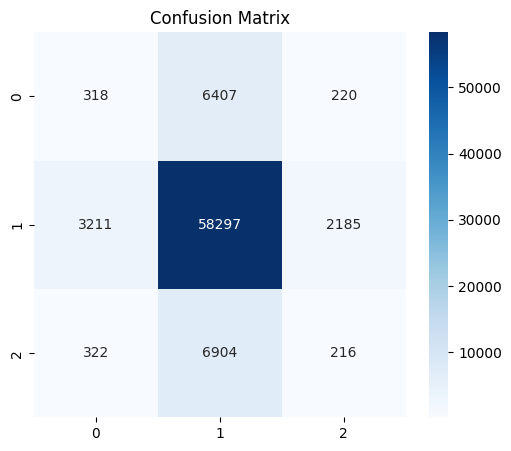


💰 --- TRADING METRICS ---
Trades: 6472
Winrate: 0.492
Avg trade: -0.000026
Total return: -0.1707
Sharpe (approx): -0.009
Max Drawdown: -0.4350


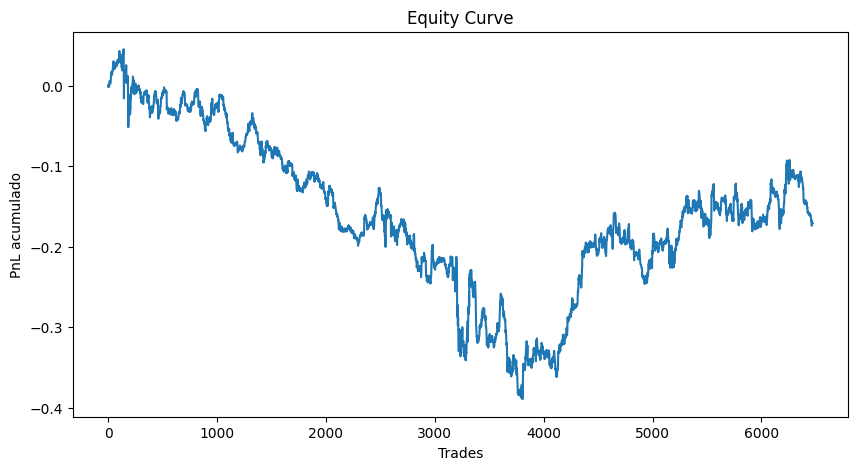


📈 --- EDGE POR SEÑAL ---
pred
0   -0.000074
1    0.000000
2    0.000044
Name: pnl, dtype: float64


{'accuracy': 0.7534707991803279,
 'winrate': np.float64(0.4919653893695921),
 'sharpe': np.float64(-0.009308976942222581),
 'total_return': np.float64(-0.17066884071526112),
 'max_dd': np.float64(-0.43503146032043494)}

In [18]:
evaluate_trading_performance(result_triple_test_2)

In [19]:
# --- Código importado/adaptado desde Metrics/dual.py: doble LSTM (movement + direction) ---
import logging
from pathlib import Path
import joblib
from sklearn.preprocessing import MinMaxScaler

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

class LSTMModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        out = self.fc(last_hidden)
        return self.sigmoid(out)

def create_sequences(df_features, target_series, seq_len):
    X, y = [], []
    for i in range(len(df_features) - seq_len):
        X.append(df_features.iloc[i:i+seq_len].values)
        y.append(target_series.iloc[i+seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

def train_single_lstm(X, y, X_val, y_val, epochs=20, batch_size=64, model_name='Model'):
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_t = torch.tensor(X).to(DEVICE)
    y_t = torch.tensor(y).to(DEVICE)
    X_v = torch.tensor(X_val).to(DEVICE)
    y_v = torch.tensor(y_val).to(DEVICE)

    # simple pos_weight if imbalance
    try:
        pos_weight = torch.tensor([(y == 0).sum() / (y == 1).sum()], device=DEVICE) if y.mean() > 0 else torch.tensor([1.0], device=DEVICE)
    except Exception:
        pos_weight = torch.tensor([1.0], device=DEVICE)

    model = LSTMModel(input_size=X.shape[2]).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    ds = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for bx, by in loader:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 5 == 0:
            model.eval()
            with torch.no_grad():
                val_out = model(X_v)
                val_loss = criterion(val_out, y_v).item()
            print(f"[{model_name}] Epoch {epoch+1}/{epochs} | Val Loss: {val_loss:.4f}")

    return model

def train_double_lstm_walkforward(df, feature_cols, movement_threshold=0.0005, walk_forward_window=180, walk_forward_step=30, walk_forward_test_size=5, sequence_length=60, epochs=25, batch_size=64, symbol='GC'):
    # df: DataFrame indexed by datetime with at least 'close' and feature_cols
    df2 = df.copy()
    df2['return_next'] = df2['close'].shift(-1) / df2['close'] - 1
    df2['movement'] = (df2['return_next'].abs() > movement_threshold).astype(int)
    df2['direction'] = (df2['return_next'] > 0).astype(int)
    df2.dropna(inplace=True)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df2[feature_cols])
    df_scaled = pd.DataFrame(scaled, columns=feature_cols, index=df2.index)

    dates = df_scaled.index.unique()
    n_windows = max(1, (len(dates) - walk_forward_window) // walk_forward_step + 1)

    best_movement_model = None
    best_direction_model = None

    for i in range(n_windows):
        train_start = i * walk_forward_step
        train_end = train_start + walk_forward_window
        test_start = train_end
        test_end = test_start + walk_forward_test_size

        train_df = df_scaled.iloc[train_start:train_end]
        test_df = df_scaled.iloc[test_start:test_end]
        if len(train_df) < sequence_length or len(test_df) < 5:
            continue

        # movement sequences
        X_move, y_move = create_sequences(train_df, df2.loc[train_df.index, 'movement'], sequence_length)
        X_move_val, y_move_val = create_sequences(test_df, df2.loc[test_df.index, 'movement'], sequence_length)

        # direction only where movement==1
        move_mask_train = df2.loc[train_df.index, 'movement'] == 1
        if move_mask_train.sum() > sequence_length:
            X_dir, y_dir = create_sequences(train_df[move_mask_train], df2.loc[train_df.index[move_mask_train], 'direction'], sequence_length)
        else:
            X_dir, y_dir = np.array([]), np.array([])

        move_mask_test = df2.loc[test_df.index, 'movement'] == 1
        if move_mask_test.sum() > sequence_length:
            X_dir_val, y_dir_val = create_sequences(test_df[move_mask_test], df2.loc[test_df.index[move_mask_test], 'direction'], sequence_length)
        else:
            X_dir_val, y_dir_val = np.array([]), np.array([])

        movement_model = train_single_lstm(X_move, y_move, X_move_val, y_move_val, epochs=epochs, batch_size=batch_size, model_name='Movement')
        direction_model = None
        if X_dir.size:
            direction_model = train_single_lstm(X_dir, y_dir, X_dir_val, y_dir_val, epochs=max(1, epochs//2), batch_size=batch_size, model_name='Direction')

        best_movement_model = movement_model
        best_direction_model = direction_model if direction_model is not None else best_direction_model

    # save final models & scaler
    final_movement_path = MODEL_DIR / f"double_movement_{symbol.lower()}.pth"
    final_movement_scaler = MODEL_DIR / f"double_movement_{symbol.lower()}_scaler.joblib"
    torch.save(best_movement_model.state_dict(), final_movement_path)
    joblib.dump(scaler, final_movement_scaler)
    print(f"Saved movement model: {final_movement_path}")
    if best_direction_model is not None:
        final_dir_path = MODEL_DIR / f"double_direction_{symbol.lower()}.pth"
        final_dir_scaler = MODEL_DIR / f"double_direction_{symbol.lower()}_scaler.joblib"
        torch.save(best_direction_model.state_dict(), final_dir_path)
        joblib.dump(scaler, final_dir_scaler)
        print(f"Saved direction model: {final_dir_path}")

    return best_movement_model, best_direction_model, scaler

# Ejemplo de uso (descomenta para ejecutar):
# movement_model, direction_model, scaler = train_double_lstm_walkforward(df_final_triple_liquid, feature_cols_triple, movement_threshold=0.0005, walk_forward_window=180, walk_forward_step=30, walk_forward_test_size=5, sequence_length=60, epochs=10, batch_size=256, symbol=ASSET)


In [22]:
movement_model, direction_model, scaler = train_double_lstm_walkforward(df_final_triple_liquid, feature_cols_triple, movement_threshold=0.0005, walk_forward_window=180, walk_forward_step=30, walk_forward_test_size=5, sequence_length=60, epochs=10, batch_size=256, symbol=ASSET)

[Movement] Epoch 5/10 | Val Loss: 0.6783
[Movement] Epoch 10/10 | Val Loss: 0.6824
[Direction] Epoch 5/5 | Val Loss: 0.6930
[Movement] Epoch 5/10 | Val Loss: 0.8354
[Movement] Epoch 10/10 | Val Loss: 0.7561
[Direction] Epoch 5/5 | Val Loss: 0.6930
[Movement] Epoch 5/10 | Val Loss: 0.6394
[Movement] Epoch 10/10 | Val Loss: 0.6471
[Direction] Epoch 5/5 | Val Loss: 0.6974
[Movement] Epoch 5/10 | Val Loss: 0.5100
[Movement] Epoch 10/10 | Val Loss: 0.5808
[Direction] Epoch 5/5 | Val Loss: 0.7871
[Movement] Epoch 5/10 | Val Loss: 0.6724
[Movement] Epoch 10/10 | Val Loss: 0.6410
[Direction] Epoch 5/5 | Val Loss: 0.8365
[Movement] Epoch 5/10 | Val Loss: 0.6528
[Movement] Epoch 10/10 | Val Loss: 0.6443
[Direction] Epoch 5/5 | Val Loss: 0.6816
[Movement] Epoch 5/10 | Val Loss: 0.6467
[Movement] Epoch 10/10 | Val Loss: 0.6364
[Direction] Epoch 5/5 | Val Loss: 0.7263
[Movement] Epoch 5/10 | Val Loss: 0.7160
[Movement] Epoch 10/10 | Val Loss: 0.6840
[Direction] Epoch 5/5 | Val Loss: 0.6567
[Movemen

In [25]:
# --- Evaluación y backtest adaptados desde Metrics/metric.py (batched para evitar OOM) ---
import logging
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

logger = logging.getLogger(__name__)


def calculate_atr(df: pd.DataFrame, period: int = 14):
    high_low = df['high'] - df['low']
    high_close = (df['high'] - df['close'].shift()).abs()
    low_close = (df['low'] - df['close'].shift()).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return tr.rolling(window=period).mean()


def _batch_predict(model, X_array, batch_size=256, device=torch.device('cpu')):
    """Yield model sigmoid probs for X_array in batches (X_array: numpy array (n, seq_len, feat))."""
    model.to(device)
    model.eval()
    probs = []
    n = len(X_array)
    for start in range(0, n, batch_size):
        end = min(n, start + batch_size)
        xb = torch.tensor(X_array[start:end], dtype=torch.float32).to(device)
        with torch.no_grad():
            logits = model(xb)
            p = torch.sigmoid(logits).cpu().numpy().flatten()
        probs.append(p)
    return np.concatenate(probs, axis=0) if probs else np.array([])


def evaluate_double_lstm(
    movement_model: torch.nn.Module,
    direction_model: torch.nn.Module,
    scaler,
    test_df: pd.DataFrame,
    feature_cols: list,
    sequence_length: int = 60,
    movement_threshold: float = 0.0005,
    batch_size: int = 256,
    device=torch.device("cpu")
):
    """Evalúa ambos modelos (movement + direction) sobre `test_df` en batches para evitar OOM.
    Devuelve métricas de clasificación y arrays de predicción discretos.
    """
    movement_model.eval()
    if direction_model is not None:
        direction_model.eval()

    # preparar scaled dataframe
    test_scaled = scaler.transform(test_df[feature_cols])
    test_scaled_df = pd.DataFrame(test_scaled, columns=feature_cols, index=test_df.index)

    X_list = []
    y_move_test = []
    y_dir_test = []
    for i in range(len(test_scaled_df) - sequence_length):
        seq = test_scaled_df.iloc[i:i+sequence_length].values
        X_list.append(seq)
        ret_next = test_df['close'].iloc[i+sequence_length] / test_df['close'].iloc[i+sequence_length-1] - 1
        move_real = 1 if abs(ret_next) > movement_threshold else 0
        dir_real = 1 if ret_next > 0 else 0
        y_move_test.append(move_real)
        y_dir_test.append(dir_real if move_real == 1 else -1)

    if len(X_list) == 0:
        raise ValueError('No test sequences available for the provided sequence_length')

    X_arr = np.array(X_list, dtype=np.float32)

    # Movement predictions (batched)
    mov_probs = _batch_predict(movement_model, X_arr, batch_size=batch_size, device=device)
    pred_move_class = (mov_probs > 0.5).astype(int)

    # Direction predictions where movement predicted 1 (batched over indices)
    move_indices = np.nonzero(pred_move_class == 1)[0]
    if len(move_indices) > 0 and direction_model is not None:
        X_dir = X_arr[move_indices]
        dir_probs = _batch_predict(direction_model, X_dir, batch_size=batch_size, device=device)
        pred_dir_class = (dir_probs > 0.5).astype(int)
    else:
        pred_dir_class = np.array([])

    metrics = {}
    # Movement metrics
    metrics['movement'] = {
        'accuracy': accuracy_score(y_move_test, pred_move_class),
        'precision': precision_score(y_move_test, pred_move_class, zero_division=0),
        'recall': recall_score(y_move_test, pred_move_class, zero_division=0),
        'f1': f1_score(y_move_test, pred_move_class, zero_division=0),
        'confusion': confusion_matrix(y_move_test, pred_move_class).tolist()
    }

    # Direction metrics (only where real movement == 1)
    real_move_idx = [i for i, v in enumerate(y_move_test) if v == 1]
    if len(real_move_idx) > 0 and len(pred_dir_class) > 0:
        # align predicted direction to real movement positions
        # pred_dir_class corresponds to move_indices order
        # extract predictions for real_move_idx among move_indices
        move_index_map = {idx: pos for pos, idx in enumerate(move_indices)}
        intersect_positions = [move_index_map[i] for i in real_move_idx if i in move_index_map]
        if len(intersect_positions) > 0:
            y_dir_real = [y_dir_test[i] for i in real_move_idx if i in move_index_map]
            preds_for_real = [pred_dir_class[pos] for pos in intersect_positions]
            metrics['direction'] = {
                'accuracy': accuracy_score(y_dir_real, preds_for_real),
                'precision': precision_score(y_dir_real, preds_for_real, zero_division=0),
                'recall': recall_score(y_dir_real, preds_for_real, zero_division=0),
                'f1': f1_score(y_dir_real, preds_for_real, zero_division=0),
            }
        else:
            metrics['direction'] = {'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}
    else:
        metrics['direction'] = {'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}

    logger.info(f"Movement → Acc: {metrics['movement']['accuracy']:.3f} | F1: {metrics['movement']['f1']:.3f}")
    logger.info(f"Direction → Acc: {metrics['direction']['accuracy']:.3f} | F1: {metrics['direction']['f1']:.3f}")

    return metrics, pred_move_class, pred_dir_class


def run_vectorized_backtest(
    df: pd.DataFrame,
    movement_model: torch.nn.Module,
    direction_model: torch.nn.Module,
    scaler,
    feature_cols: list,
    initial_capital: float = 100_000,
    atr_period: int = 14,
    atr_trail_mult: float = 1.5,
    sl_puntos: float = 20.0,
    tp_puntos: float = 40.0,
    position_size_contracts: int = 1,
    sequence_length: int = 60,
    batch_size: int = 256,
    device=torch.device("cpu")
):
    """Backtest vectorizado para la estrategia double-LSTM. Procesa inferencia en batches."""
    df = df.copy()
    df['atr'] = calculate_atr(df, atr_period)

    scaled = scaler.transform(df[feature_cols])
    scaled_df = pd.DataFrame(scaled, columns=feature_cols, index=df.index)

    X = []
    for i in range(len(scaled_df) - sequence_length):
        X.append(scaled_df.iloc[i:i+sequence_length].values)
    if len(X) == 0:
        raise ValueError('No sequences for backtest with given sequence_length')
    X_arr = np.array(X, dtype=np.float32)

    # Movement predictions batched
    mov_probs = _batch_predict(movement_model, X_arr, batch_size=batch_size, device=device)
    pred_move_class = (mov_probs > 0.5).astype(int)

    # Direction predictions for movement==1
    move_indices = np.nonzero(pred_move_class == 1)[0]
    if len(move_indices) > 0 and direction_model is not None:
        X_dir = X_arr[move_indices]
        dir_probs = _batch_predict(direction_model, X_dir, batch_size=batch_size, device=device)
        pred_dir_class = (dir_probs > 0.5).astype(int)
    else:
        pred_dir_class = np.array([])

    signals = np.zeros(len(df) - sequence_length)
    signals[pred_move_class == 0] = 0
    signals[pred_move_class == 1] = 1
    dir_idx = 0
    for i in range(len(signals)):
        if pred_move_class[i] == 1 and dir_idx < len(pred_dir_class):
            signals[i] = 1 if pred_dir_class[dir_idx] == 1 else -1
            dir_idx += 1

    equity = [initial_capital]
    position = 0
    entry_price = 0
    trades = []
    equity_curve = np.zeros(len(df))

    for i in range(sequence_length, len(df)):
        sig = signals[i - sequence_length]
        price = df['close'].iloc[i]
        atr = df['atr'].iloc[i]

        if position != 0:
            if sig == 0 or (sig > 0 and position < 0) or (sig < 0 and position > 0):
                pnl = (price - entry_price) * position * 50
                equity[-1] += pnl
                trades.append(pnl)
                position = 0

        if position == 0 and sig != 0:
            position = int(sig * position_size_contracts)
            entry_price = price
            sl = price - sl_puntos if sig > 0 else price + sl_puntos
            tp = price + tp_puntos if sig > 0 else price - tp_puntos

        if position != 0:
            if position > 0:
                new_sl = price - (atr * atr_trail_mult)
                if new_sl > sl:
                    sl = new_sl
            else:
                new_sl = price + (atr * atr_trail_mult)
                if new_sl < sl:
                    sl = new_sl

            if (position > 0 and price <= sl) or (position < 0 and price >= sl):
                pnl = (price - entry_price) * position * 50
                equity[-1] += pnl
                trades.append(pnl)
                position = 0
            elif (position > 0 and price >= tp) or (position < 0 and price <= tp):
                pnl = (price - entry_price) * position * 50
                equity[-1] += pnl
                trades.append(pnl)
                position = 0

        equity_curve[i] = equity[-1]

    returns = np.diff(equity_curve[equity_curve > 0]) / equity_curve[:-1][equity_curve[:-1] > 0]
    sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252 * 24 * 60) if len(returns) > 1 else 0
    max_dd = np.max(np.maximum.accumulate(equity_curve) - equity_curve) / np.maximum.accumulate(equity_curve).max()
    win_rate = len([t for t in trades if t > 0]) / len(trades) if trades else 0
    profit_factor = sum(t for t in trades if t > 0) / abs(sum(t for t in trades if t < 0)) if any(t < 0 for t in trades) else float('inf')

    metrics = {
        'sharpe': float(sharpe),
        'max_drawdown_pct': float(max_dd * 100),
        'win_rate': float(win_rate),
        'profit_factor': float(profit_factor),
        'total_trades': len(trades),
        'final_equity': float(equity[-1]),
        'total_return_pct': float((equity[-1] / initial_capital - 1) * 100),
        'equity_curve': equity_curve.tolist()
    }

    logger.info(f"BACKTEST → Sharpe: {metrics['sharpe']:.2f} | MaxDD: {metrics['max_drawdown_pct']:.2f}% | "
                f"WinRate: {metrics['win_rate']:.1f}% | PF: {metrics['profit_factor']:.2f} | Trades: {metrics['total_trades']}")

    return metrics, equity_curve


In [26]:
evaluate_double_lstm(movement_model, direction_model, scaler, df_final_triple_liquid, feature_cols_triple, sequence_length=60, movement_threshold=0.0005)

({'movement': {'accuracy': 0.3571819817939957,
   'precision': 0.0,
   'recall': 0.0,
   'f1': 0.0,
   'confusion': [[27388, 0], [49290, 0]]},
  'direction': {'accuracy': 0.0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0}},
 array([0, 0, 0, ..., 0, 0, 0], shape=(76678,)),
 array([], dtype=float64))

In [27]:
print("feature_cols length:", len(feature_cols_triple))
print("test_df idx head/tail:", df_final_triple_liquid.index[:3], df_final_triple_liquid.index[-3:])
# check scaler transform shape
print("scaled shape:", scaler.transform(df_final_triple_liquid[feature_cols_triple]).shape)

feature_cols length: 140
test_df idx head/tail: RangeIndex(start=0, stop=3, step=1) RangeIndex(start=76735, stop=76738, step=1)
scaled shape: (76738, 140)


In [28]:
# Diagnóstico rápido de movimiento: distribuciones, AUC, logits y checks de scaler
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix

device = torch.device('cpu')
batch_size = 128
seq_len = 60
feat_cols = feature_cols_triple
test_df_local = df_final_triple_liquid

# Escalado completo y secuencias (igual que en evaluate_double_lstm)
scaled_all = scaler.transform(test_df_local[feat_cols])
scaled_df = pd.DataFrame(scaled_all, columns=feat_cols, index=test_df_local.index)
X_list = []
y_move = []
for i in range(len(scaled_df) - seq_len):
    X_list.append(scaled_df.iloc[i:i+seq_len].values)
    ret_next = test_df_local['close'].iloc[i+seq_len] / test_df_local['close'].iloc[i+seq_len-1] - 1
    move_real = 1 if abs(ret_next) > 0.0005 else 0
    y_move.append(move_real)

X_arr = np.array(X_list, dtype=np.float32)
print('Sequences:', X_arr.shape)
print('True movement counts:', np.unique(y_move, return_counts=True))

# Batch predict movement probs
mov_probs = _batch_predict(movement_model, X_arr, batch_size=batch_size, device=device)
print('mov_probs shape:', mov_probs.shape)
print('mov_probs percentiles:', np.percentile(mov_probs, [0,1,5,10,25,50,75,90,95,99,100]))
print('predicted counts @0.5:', np.unique((mov_probs>0.5).astype(int), return_counts=True))

# ROC AUC if possible
if len(np.unique(y_move)) > 1:
    try:
        print('ROC AUC:', roc_auc_score(y_move, mov_probs))
    except Exception as e:
        print('ROC AUC error:', e)
else:
    print('Only one label present in y_move; ROC AUC not defined.')

# Threshold sweep
from sklearn.metrics import confusion_matrix
for thr in [0.5, 0.4, 0.3, 0.2, 0.1]:
    preds = (mov_probs > thr).astype(int)
    cm = confusion_matrix(y_move, preds)
    print(f'thr={thr}: preds positives={preds.sum()} | confusion={cm.tolist()}')

# Show some logits for first few samples
import torch
with torch.no_grad():
    sample_x = torch.tensor(X_arr[:8], dtype=torch.float32).to(device)
    logits = movement_model(sample_x).squeeze(-1).cpu().numpy()
    probs = 1 / (1 + np.exp(-logits))
    print('sample logits:', logits)
    print('sample probs:', probs)

# Check movement_model parameter magnitudes (sanity)
params_sum = sum(p.abs().sum().item() for p in movement_model.parameters())
print('sum absolute params:', params_sum)

# Check scaler attributes
print('scaler type:', type(scaler))
for attr in ['center_', 'scale_', 'n_features_in_']:
    print(attr, getattr(scaler, attr, 'MISSING'))

# Compare to training scaler variable if present in kernel
if 'sc_triple_test_2' in globals():
    print('scaler is sc_triple_test_2?', scaler is sc_triple_test_2)
    # brief compare of first 5 scales
    try:
        print('scaler.scale_[:5]:', getattr(scaler, 'scale_', None)[:5])
        print('sc_triple_test_2.scale_[:5]:', getattr(sc_triple_test_2, 'scale_', None)[:5])
    except Exception:
        pass

print('\nDiagnostics cell finished.')


Sequences: (76678, 60, 140)
True movement counts: (array([0, 1]), array([27388, 49290]))
mov_probs shape: (76678,)
mov_probs percentiles: [0.37890133 0.39415766 0.40377256 0.41013331 0.42252563 0.43998128
 0.45507845 0.46428336 0.46879049 0.4749757  0.48371395]
predicted counts @0.5: (array([0]), array([76678]))
ROC AUC: 0.5274543556474777
thr=0.5: preds positives=0 | confusion=[[27388, 0], [49290, 0]]
thr=0.4: preds positives=74386 | confusion=[[886, 26502], [1406, 47884]]
thr=0.3: preds positives=76678 | confusion=[[0, 27388], [0, 49290]]
thr=0.2: preds positives=76678 | confusion=[[0, 27388], [0, 49290]]
thr=0.1: preds positives=76678 | confusion=[[0, 27388], [0, 49290]]
sample logits: [-0.35765517 -0.33744052 -0.3220484  -0.27849782 -0.23239362 -0.19839647
 -0.17341954 -0.15945572]
sample probs: [0.4115273  0.41643134 0.42017663 0.4308221  0.44216168 0.45056295
 0.45675346 0.46022034]
sum absolute params: 11986.764505002648
scaler type: <class 'sklearn.preprocessing._data.MinMaxSca